# Task 1 — Exploratory Data Analysis
## Heart Disease Dataset (Cleveland Subset)

This notebook performs a systematic exploratory data analysis (EDA) of the Cleveland Heart Disease dataset as provided for MLCB2026 Assignment 2. The goal is to understand the structure, quality, and statistical properties of the data before building any predictive models. Findings from this analysis directly inform preprocessing decisions, feature engineering choices, and model selection in subsequent tasks.

The dataset contains **242 patient records** from the Cleveland Clinic Foundation, each described by 13 clinical features. The binary classification target (`num`) indicates the presence (1) or absence (0) of coronary artery disease.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# visual style throughout the notebook
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PALETTE = {0: '#4C72B0', 1: '#DD8452'}   # blue = no disease, orange = disease
SEED = 42
np.random.seed(SEED)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Dataset Overview and Descriptive Statistics

### 1.1 Loading and Initial Inspection

We begin by loading the dataset and inspecting its basic structure: dimensions, data types, and whether the column names and value ranges match the expected feature definitions from the assignment specification.

In [7]:
# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv('../data/students_dataset.csv')

print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'\nColumn names: {df.columns.tolist()}')
print(f'\nData types:\n{df.dtypes}')
df.head(10)

Dataset shape: 242 rows × 14 columns

Column names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Data types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
num           int64
dtype: object


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,48.0,1.0,4.0,124.0,274.0,0.0,2.0,166.0,0.0,0.5,2.0,0.0,7.0,1
1,55.0,1.0,2.0,130.0,262.0,0.0,0.0,155.0,0.0,0.0,1.0,0.0,3.0,0
2,54.0,0.0,2.0,132.0,288.0,1.0,2.0,159.0,1.0,0.0,1.0,1.0,3.0,0
3,54.0,1.0,2.0,108.0,309.0,0.0,0.0,156.0,0.0,0.0,1.0,0.0,7.0,0
4,57.0,0.0,4.0,140.0,241.0,0.0,0.0,123.0,1.0,0.2,2.0,0.0,7.0,1
5,48.0,1.0,4.0,130.0,256.0,1.0,2.0,150.0,1.0,0.0,1.0,2.0,7.0,1
6,54.0,1.0,4.0,124.0,266.0,0.0,2.0,109.0,1.0,2.2,2.0,1.0,7.0,1
7,55.0,1.0,4.0,140.0,217.0,0.0,0.0,111.0,1.0,5.6,3.0,0.0,7.0,1
8,65.0,0.0,3.0,155.0,269.0,0.0,0.0,148.0,0.0,0.8,1.0,0.0,3.0,0
9,46.0,1.0,4.0,140.0,311.0,0.0,0.0,120.0,1.0,1.8,2.0,2.0,7.0,1


All 13 features and the target variable `num` are present. Every feature is stored as `float64`, and the target as `int64`. Although several features are conceptually categorical or binary (e.g., `sex`, `cp`, `thal`), they are already numerically encoded — no string-to-integer conversion is needed.

In [8]:
# Verify that each feature's observed values match the expected coding scheme.
print('Unique values per feature:')
print('-' * 45)
for col in df.columns:
    uvals = sorted(df[col].dropna().unique())
    n_missing = df[col].isnull().sum()
    missing_str = f'  ⚠ {n_missing} missing' if n_missing > 0 else ''
    print(f'  {col:10s}: {uvals}{missing_str}')

Unique values per feature:
---------------------------------------------
  age       : [np.float64(29.0), np.float64(34.0), np.float64(35.0), np.float64(37.0), np.float64(38.0), np.float64(39.0), np.float64(40.0), np.float64(41.0), np.float64(42.0), np.float64(43.0), np.float64(44.0), np.float64(45.0), np.float64(46.0), np.float64(47.0), np.float64(48.0), np.float64(49.0), np.float64(50.0), np.float64(51.0), np.float64(52.0), np.float64(53.0), np.float64(54.0), np.float64(55.0), np.float64(56.0), np.float64(57.0), np.float64(58.0), np.float64(59.0), np.float64(60.0), np.float64(61.0), np.float64(62.0), np.float64(63.0), np.float64(64.0), np.float64(65.0), np.float64(66.0), np.float64(67.0), np.float64(68.0), np.float64(69.0), np.float64(70.0), np.float64(71.0), np.float64(76.0), np.float64(77.0)]
  sex       : [np.float64(0.0), np.float64(1.0)]
  cp        : [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
  trestbps  : [np.float64(94.0), np.float64(100.0), np.float

**Coding notes:**
- `cp` (chest pain type) uses values 1–4, which is the original Cleveland 1-indexed encoding (1 = typical angina, 2 = atypical angina, 3 = non-anginal pain, 4 = asymptomatic). The assignment table lists 0–3. The relative ordering and clinical meaning are identical.
- `thal` uses values {3, 6, 7}: these are the raw Cleveland codes (3 = normal, 6 = fixed defect, 7 = reversible defect), not the simplified 1/2/3 encoding. All three represent distinct physiological states and will be treated as a nominal categorical feature.
- `slope` and `restecg` are also 1-indexed (1–3 and 0–2 respectively), consistent with the original dataset.
- Two missing values are present: one in `ca` and one in `thal`. Both are categorical/ordinal features; we will handle these via mode imputation **strictly within the training fold** to prevent data leakage.

### 1.2 Descriptive Statistics

In [9]:
# ── Summary statistics ────────────────────────────────────────────────────────
desc = df.describe().T
desc['missing'] = df.isnull().sum()
desc['missing_%'] = (df.isnull().sum() / len(df) * 100).round(2)
pd.set_option('display.float_format', '{:.2f}'.format)
desc[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'missing', 'missing_%']]

,count,mean,std,min,25%,50%,75%,max,missing,missing_%
age,242.00,54.55,9.00,29.00,48.00,56.00,61.00,77.00,0,0.00
sex,242.00,0.68,0.47,0.00,0.00,1.00,1.00,1.00,0,0.00
cp,242.00,3.15,0.98,1.00,2.25,3.00,4.00,4.00,0,0.00
trestbps,242.00,130.96,17.62,94.00,120.00,130.00,140.00,200.00,0,0.00
chol,242.00,249.84,52.85,126.00,212.00,244.50,277.75,564.00,0,0.00
fbs,242.00,0.14,0.35,0.00,0.00,0.00,0.00,1.00,0,0.00
restecg,242.00,0.98,1.00,0.00,0.00,0.00,2.00,2.00,0,0.00
thalach,242.00,149.96,22.69,71.00,134.50,153.50,166.00,202.00,0,0.00
exang,242.00,0.33,0.47,0.00,0.00,0.00,1.00,1.00,0,0.00
oldpeak,242.00,1.00,1.12,0.00,0.00,0.80,1.60,6.20,0,0.00


**Key observations from descriptive statistics:**
- **Age** ranges from 29 to 77 years (mean ≈ 54.5, SD ≈ 9.0), reflecting a middle-aged to elderly clinical population consistent with coronary artery disease epidemiology.
- **Cholesterol (`chol`)** has a maximum value of 564 mg/dL. While clinically extreme, such values have been documented in severe hypercholesterolaemia. We will examine this further in the outlier analysis.
- **Resting blood pressure (`trestbps`)** reaches 200 mmHg.
- **Max heart rate (`thalach`)** minimum is 71 bpm, which is low for exercise-induced heart rate, suggesting the patient may have had a limited exercise capacity.
- **Missing values** are minimal (< 0.5% of total data): 1 in `ca`, 1 in `thal`.

### 1.3 Duplicate Rows

In [10]:
# ── Duplicate check ───────────────────────────────────────────────────────────
n_dupes = df.duplicated().sum()
print(f'Number of exact duplicate rows: {n_dupes}')
if n_dupes > 0:
    print('Duplicate rows:')
    display(df[df.duplicated(keep=False)])

Number of exact duplicate rows: 0


### 1.4 Class Distribution and Imbalance Assessment

Class imbalance can bias classifiers toward the majority class and inflate accuracy as a performance metric. We assess the degree of imbalance here to guide both our cross-validation strategy (stratified folds) and our choice of evaluation metrics.

Target distribution:
  Class 0 (No disease): 131  (54.1%)
  Class 1 (Disease):    111  (45.9%)
  Imbalance ratio:      1.18:1


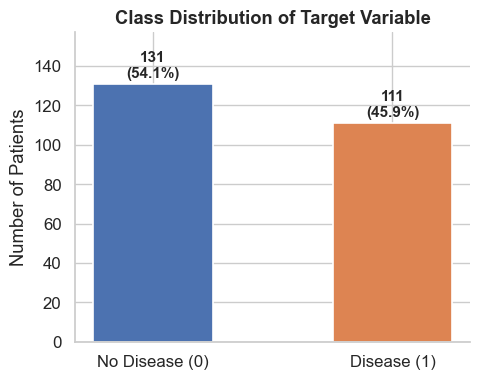

In [12]:
# ── Class distribution ────────────────────────────────────────────────────────
class_counts = df['num'].value_counts().sort_index()
class_pct    = df['num'].value_counts(normalize=True).sort_index() * 100

print('Target distribution:')
print(f'  Class 0 (No disease): {class_counts[0]:3d}  ({class_pct[0]:.1f}%)')
print(f'  Class 1 (Disease):    {class_counts[1]:3d}  ({class_pct[1]:.1f}%)')
print(f'  Imbalance ratio:      {class_counts[0]/class_counts[1]:.2f}:1')

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['No Disease (0)', 'Disease (1)'], class_counts.values,
              color=[PALETTE[0], PALETTE[1]], edgecolor='white', linewidth=1.2, width=0.5)
for bar, count, pct in zip(bars, class_counts.values, class_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Patients')
ax.set_title('Class Distribution of Target Variable', fontweight='bold')
ax.set_ylim(0, class_counts.max() * 1.2)
sns.despine()
plt.tight_layout()
plt.savefig('../figures/fig_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

The dataset exhibits **mild class imbalance**: 131 patients without heart disease (54.1%) versus 111 with disease (45.9%), yielding a 1.18:1 ratio. This degree of imbalance is moderate and unlikely to require aggressive resampling techniques (e.g., SMOTE). However, it does mean that **accuracy alone is an insufficient metric** — a naive majority-class classifier would achieve ~54% accuracy. We therefore prioritise metrics that account for imbalance: Matthews Correlation Coefficient (MCC), Area Under the ROC Curve (AUC), Balanced Accuracy (BA), and Precision-Recall AUC (PRAUC).

Additionally, all cross-validation folds will use **stratified splitting** to ensure each fold preserves the overall 54:46 class ratio.

### 1.5 Outlier Detection

We use the **Z-score method** alongside the IQR method to flag potential outliers in continuous features. A value is flagged by IQR if it falls more than 1.5 × IQR below Q1 or above Q3; by Z-score if |z| > 3. We report counts rather than removing values — outliers in clinical data often represent real extreme cases and should not be discarded without clinical justification. The Z-score method is included here for completeness, but the IQR method is preferred as our dataset contains skewed features (e.g., `oldpeak`) and the Z-score's reliance on the mean and SD makes it sensitive to the very outliers it aims to detect.

In [14]:
# ── Outlier detection (IQR + Z-score) ───────────────────────────────────────
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

print('Outlier summary:')
print(f'{"Feature":<12} {"IQR outliers":>14} {"Z>3 outliers":>14}')
print('-' * 42)
for feat in continuous_features:
    # IQR method
    q1, q3 = df[feat].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_iqr = ((df[feat] < lo) | (df[feat] > hi)).sum()
    # Z-score method
    z = np.abs(stats.zscore(df[feat].dropna()))
    n_z = (z > 3).sum()
    print(f'{feat:<12} {n_iqr:>14} {n_z:>14}')


Outlier summary:
Feature        IQR outliers   Z>3 outliers
------------------------------------------
age                       0              0
trestbps                  6              2
chol                      5              3
thalach                   1              1
oldpeak                   4              2


**Outlier notes:**
- `chol = 564 mg/dL` is the most extreme outlier, flagged by both methods. This value is retained as a genuine clinical observation — it may reflect severe familial hypercholesterolaemia.
- `oldpeak` outliers (high ST depression values) are clinically meaningful indicators of ischaemia and are retained.
- The Z-score method flags fewer outliers than IQR for skewed features like `oldpeak` because the extreme values inflate the SD, compressing the z-scores of other points. This confirms that IQR is the more appropriate method here.
- **Scaling decision:** `StandardScaler` will be applied to continuous features inside the modelling pipeline via a `ColumnTransformer` (fitted on training folds only). The `chol` outlier is retained; its influence on the mean and SD within any training fold is minor given the dataset size.

## 2. Feature Assessment and Visualization

### 2.1 Distribution of Continuous Features by Class

Box plots to compare the distribution of each continuous feature between patients with and without heart disease. Separation between the two distributions provides a rudimentary indication of a feature's discriminative power.

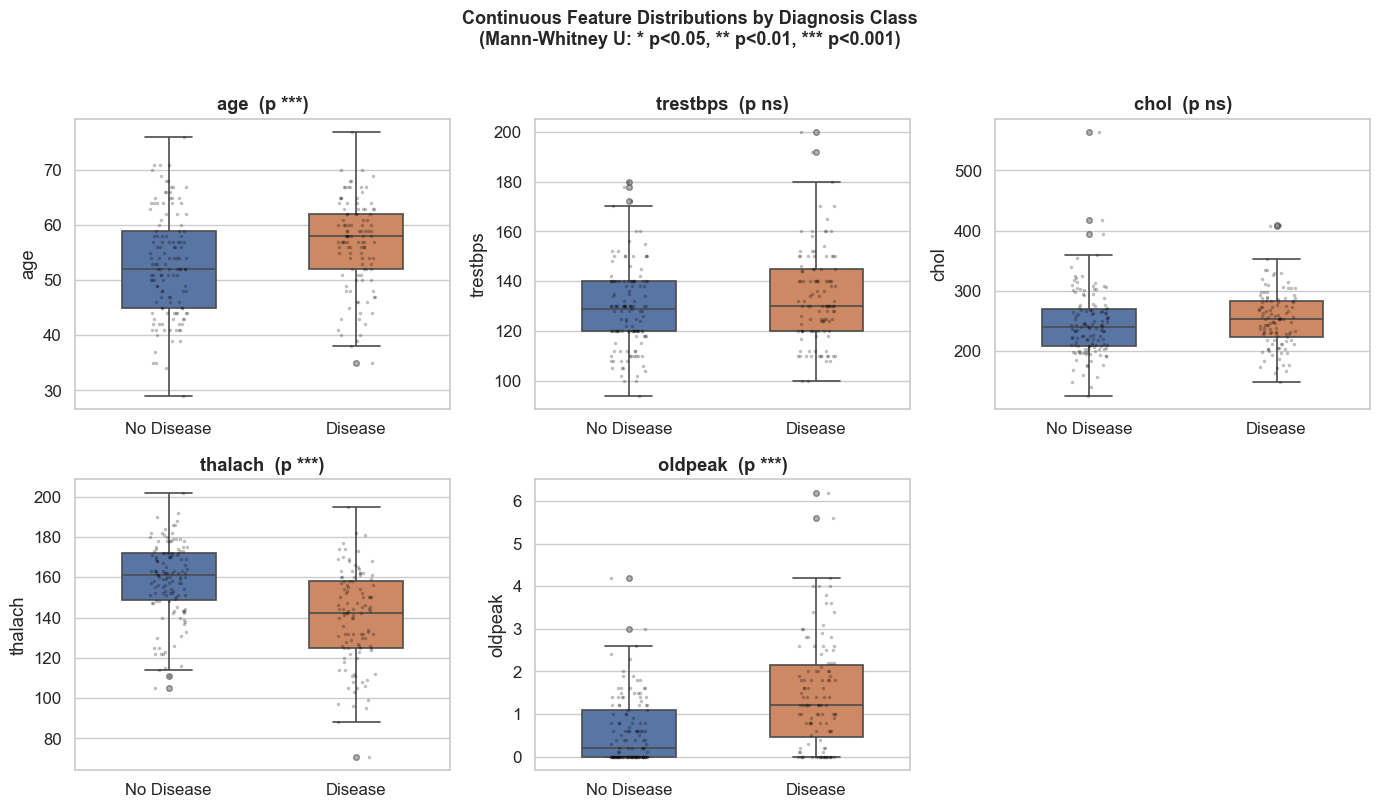

In [15]:
# ── Boxplots: continuous features by class ────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

labels = {0: 'No Disease', 1: 'Disease'}
df_plot = df.copy()
df_plot['Diagnosis'] = df_plot['num'].map(labels)

for i, feat in enumerate(continuous_features):
    sns.boxplot(
        data=df_plot, x='Diagnosis', y=feat, ax=axes[i],
        palette={'No Disease': PALETTE[0], 'Disease': PALETTE[1]},
        order=['No Disease', 'Disease'], width=0.5, linewidth=1.2,
        flierprops=dict(marker='o', markerfacecolor='grey', markersize=4, alpha=0.6)
    )
    # Overlay individual data points
    sns.stripplot(
        data=df_plot, x='Diagnosis', y=feat, ax=axes[i],
        order=['No Disease', 'Disease'],
        color='black', size=2.5, alpha=0.25, jitter=True
    )
    # Mann-Whitney U test for group difference
    grp0 = df.loc[df['num']==0, feat].dropna()
    grp1 = df.loc[df['num']==1, feat].dropna()
    stat, p = stats.mannwhitneyu(grp0, grp1, alternative='two-sided')
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    axes[i].set_title(f'{feat}  (p {sig})', fontweight='bold')
    axes[i].set_xlabel('')

axes[-1].set_visible(False)  # hide unused subplot
fig.suptitle('Continuous Feature Distributions by Diagnosis Class\n(Mann-Whitney U: * p<0.05, ** p<0.01, *** p<0.001)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figures/fig_boxplots_continuous.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations:**
- **`thalach` (max heart rate)** shows strong separation: patients with heart disease achieve significantly lower maximum heart rates during exercise, consistent with reduced cardiac reserve in the presence of coronary artery disease.
- **`oldpeak` (ST depression)** is markedly higher in the disease group, reflecting exercise-induced ischaemia — a clinically well-established marker.
- **`age`** is modestly higher in the disease group, consistent with the known age-related increase in CAD risk.
- **`chol`** and **`trestbps`** show less clear separation, suggesting they may be weaker individual predictors in this dataset, though they remain clinically relevant in combination.

All differences except `chol` reached statistical significance by Mann-Whitney U test (non-parametric, appropriate given the distributional shapes).

### 2.2 Distribution of Categorical/Binary Features by Class

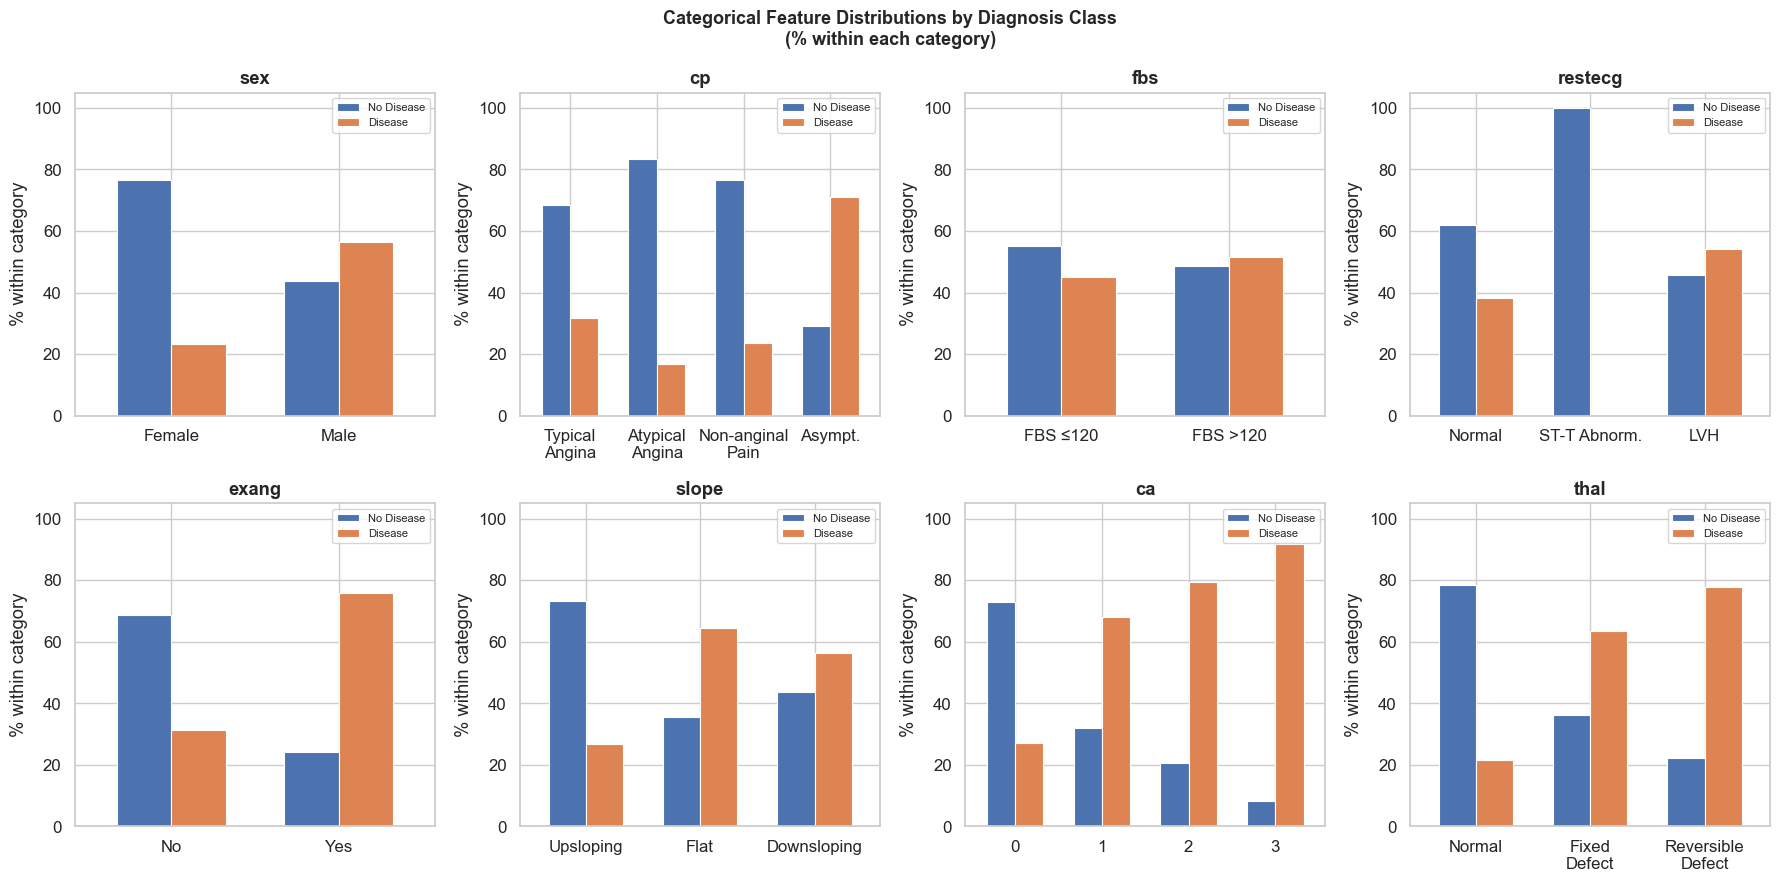

In [ ]:
# ── Stacked bar charts: categorical features by class ─────────────────────────
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# cleaner plots
feat_labels = {
    'sex':     {0: 'Female', 1: 'Male'},
    'cp':      {1: 'Typical\nAngina', 2: 'Atypical\nAngina', 3: 'Non-anginal\nPain', 4: 'Asympt.'},
    'fbs':     {0: 'FBS ≤120', 1: 'FBS >120'},
    'restecg': {0: 'Normal', 1: 'ST-T Abnorm.', 2: 'LVH'},
    'exang':   {0: 'No', 1: 'Yes'},
    'slope':   {1: 'Upsloping', 2: 'Flat', 3: 'Downsloping'},
    'ca':      {0: '0', 1: '1', 2: '2', 3: '3'},
    'thal':    {3: 'Normal', 6: 'Fixed\nDefect', 7: 'Reversible\nDefect'}
}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, feat in enumerate(categorical_features):
    ct = pd.crosstab(df[feat], df['num'], normalize='index') * 100
    ct.columns = ['No Disease', 'Disease']
    # Rename index using label map
    if feat in feat_labels:
        ct.index = [feat_labels[feat].get(v, str(v)) for v in ct.index]
    ct.plot(kind='bar', ax=axes[i], color=[PALETTE[0], PALETTE[1]],
            edgecolor='white', linewidth=0.8, width=0.65)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_ylabel('% within category')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(fontsize=8)
    axes[i].set_ylim(0, 105)

fig.suptitle('Categorical Feature Distributions by Diagnosis Class\n(% within each category)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/fig_barplots_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations:**
- **`cp` (chest pain type)**: Asymptomatic chest pain (type 4) is paradoxically associated with the highest disease prevalence — a well-known clinical finding where silent ischaemia is common in CAD. Atypical angina (type 2) shows the lowest disease rate here.
- **`exang` (exercise-induced angina)**: Patients with exercise-induced angina have substantially higher disease rates — consistent with ischaemia triggered by increased cardiac demand.
- **`thal`**: Reversible defects (code 7) are strongly associated with disease; a normal thallium scan (code 3) is associated with no disease.
- **`ca`** (number of vessels): Higher vessel count is associated with higher disease prevalence.
- **`sex`**: Males show higher disease rates, consistent with epidemiological data on sex differences in CAD risk.
- **`fbs`** shows little discriminative power in this dataset.

### 2.3 Correlation Analysis

A Pearson correlation heatmap provides a compact overview of linear associations between all features and the target. While not all relationships are linear, this serves as a useful first-pass screen.

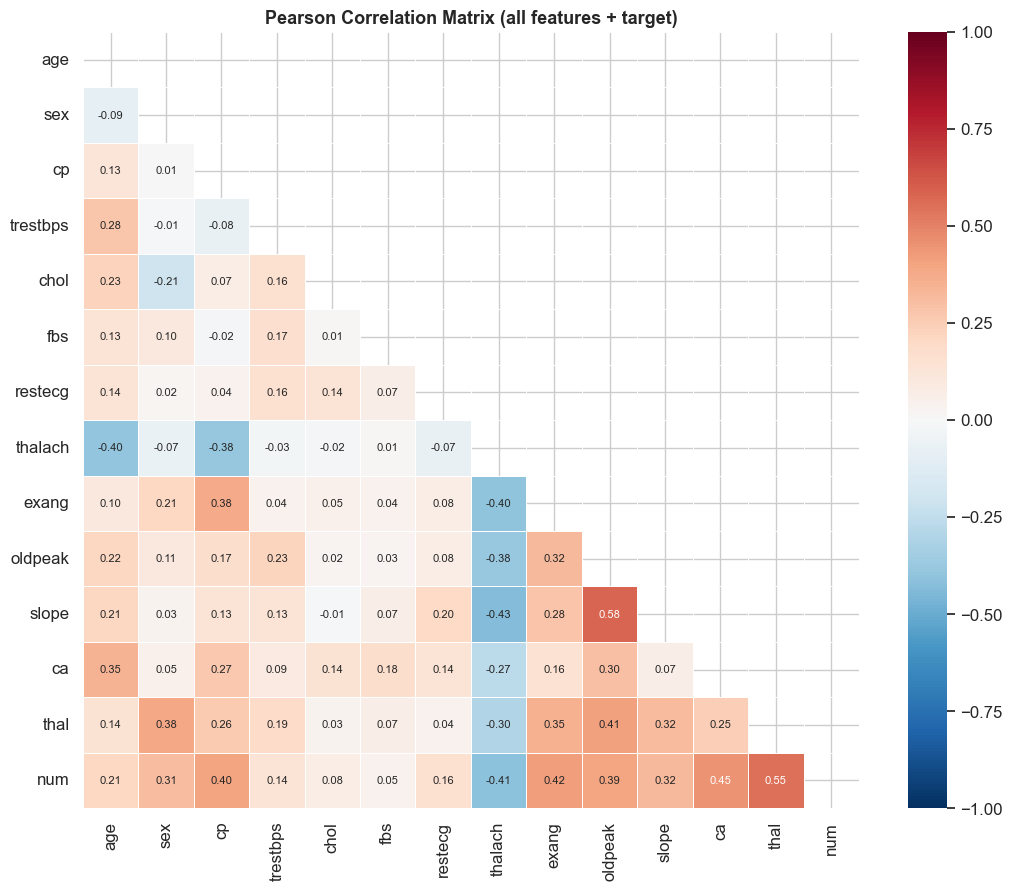


Feature correlations with target |r| (descending):
  thal       |r|=0.550  ████████████████
  ca         |r|=0.453  █████████████
  exang      |r|=0.420  ████████████
  thalach    |r|=0.409  ████████████
  cp         |r|=0.401  ████████████
  oldpeak    |r|=0.392  ███████████
  slope      |r|=0.323  █████████
  sex        |r|=0.308  █████████
  age        |r|=0.210  ██████
  restecg    |r|=0.160  ████
  trestbps   |r|=0.136  ████
  chol       |r|=0.077  ██
  fbs        |r|=0.046  █


In [18]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
corr = df.corr(method='pearson')

# Mask upper triangle for cleaner display
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    vmin=-1, vmax=1, center=0, square=True, linewidths=0.4,
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Pearson Correlation Matrix (all features + target)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../figures/fig_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Highlight top correlations with target
target_corr = corr['num'].drop('num').abs().sort_values(ascending=False)
print('\nFeature correlations with target |r| (descending):')
for feat, val in target_corr.items():
    bar = '█' * int(val * 30)
    print(f'  {feat:10s} |r|={val:.3f}  {bar}')

**Observations:**
- The features most correlated with the target (`num`) are `cp`, `thal`, `ca`, `thalach` (negatively), `exang`, and `oldpeak` — consistent with the box plot and bar chart findings above.
- **No severe multicollinearity** is evident between feature pairs (|r| < 0.7 for all pairs), suggesting that most features contribute independent information.
- `thalach` and `age` are moderately negatively correlated (as expected: maximum exercise heart rate declines with age).
- `slope` and `oldpeak` are moderately correlated with each other, both reflecting exercise-induced ischaemia through different measurements.

### 2.4 Dimensionality Reduction — PCA

Principal Component Analysis (PCA) provides a linear projection of the 13-dimensional feature space onto two dimensions, allowing us to visualise class separability in a reduced space. Before applying PCA we standardise all features, as PCA is sensitive to scale.

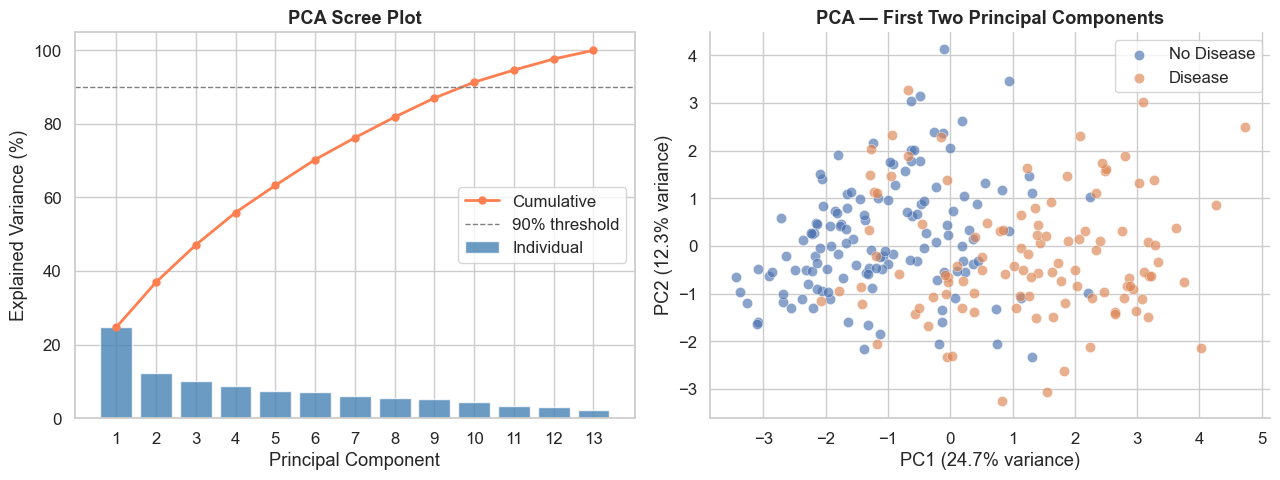

  6 components needed to explain ≥70% variance
  8 components needed to explain ≥80% variance
  10 components needed to explain ≥90% variance
  12 components needed to explain ≥95% variance


In [20]:
# ── PCA ───────────────────────────────────────────────────────────────────────
# Use complete cases only for PCA (drop the 2 rows with missing values)
df_complete = df.dropna().copy()
X = df_complete.drop('num', axis=1).values
y = df_complete['num'].values

# Standardise before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Full PCA to inspect explained variance
pca_full = PCA(random_state=SEED)
pca_full.fit(X_scaled)
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

# 2D PCA for scatter plot
pca_2d = PCA(n_components=2, random_state=SEED)
X_pca = pca_2d.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Screen plot ---
axes[0].bar(range(1, len(explained)+1), explained*100, color='steelblue',
            alpha=0.8, label='Individual')
axes[0].plot(range(1, len(explained)+1), cumulative*100, 'o-',
             color='coral', linewidth=2, markersize=5, label='Cumulative')
axes[0].axhline(90, color='grey', linestyle='--', linewidth=1, label='90% threshold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('PCA Scree Plot', fontweight='bold')
axes[0].legend()
axes[0].set_xticks(range(1, len(explained)+1))

# --- 2D scatter ---
for cls, label, color in [(0, 'No Disease', PALETTE[0]), (1, 'Disease', PALETTE[1])]:
    mask = y == cls
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=label,
                    alpha=0.65, edgecolors='white', linewidths=0.4, s=55)
axes[1].set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)')
axes[1].set_title('PCA — First Two Principal Components', fontweight='bold')
axes[1].legend()
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig('../figures/fig_pca.png', dpi=150, bbox_inches='tight')
plt.show()

# Report variance thresholds
for threshold in [70, 80, 90, 95]:
    n_comp = np.argmax(cumulative >= threshold/100) + 1
    print(f'  {n_comp} components needed to explain ≥{threshold}% variance')

**Observations:**
- The first two principal components explain a moderate proportion of total variance. The classes show partial overlap in 2D PCA space, indicating that the classification problem is not trivially separable through linear projections alone — non-linear classifiers may provide an advantage.
- The scree plot confirms that the dataset's variance is distributed across many components, suggesting that most features contribute meaningful information and aggressive dimensionality reduction (e.g., retaining only 2–3 PCs) would discard substantial signal.
- The partial class separation visible in the 2D PCA plot is encouraging: there is structure in the feature space that a classifier can exploit.

### 2.5 Point-Biserial Correlations — Statistical Feature Ranking

For a more rigorous assessment of individual feature-target associations, we compute point-biserial correlations (equivalent to Pearson r when one variable is binary) and apply Bonferroni correction for multiple comparisons.

Point-biserial correlations with target (Bonferroni corrected):
 feature     r  abs_r    p  p_bonferroni  significant
    thal  0.55   0.55 0.00          0.00         True
      ca  0.45   0.45 0.00          0.00         True
   exang  0.42   0.42 0.00          0.00         True
 thalach -0.41   0.41 0.00          0.00         True
      cp  0.40   0.40 0.00          0.00         True
 oldpeak  0.39   0.39 0.00          0.00         True
   slope  0.32   0.32 0.00          0.00         True
     sex  0.31   0.31 0.00          0.00         True
     age  0.21   0.21 0.00          0.01         True
 restecg  0.16   0.16 0.01          0.16        False
trestbps  0.14   0.14 0.03          0.45        False
    chol  0.08   0.08 0.23          1.00        False
     fbs  0.05   0.05 0.48          1.00        False


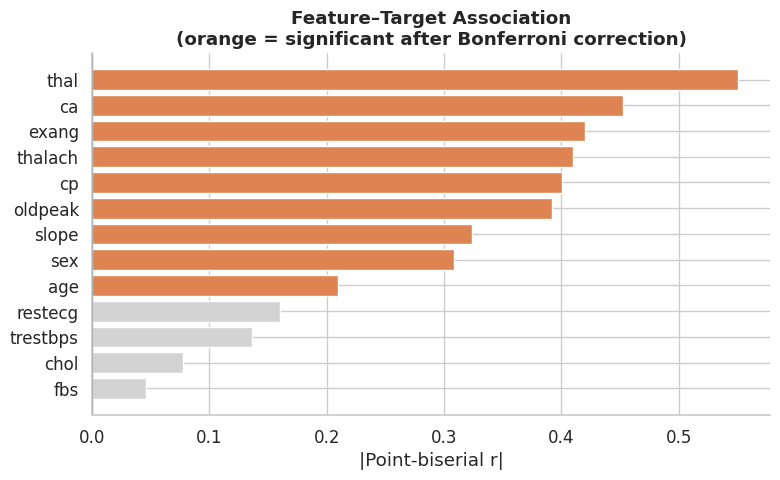

In [ ]:
# ── Point-biserial correlation with target ────────────────────────────────────
from scipy.stats import pointbiserialr

feature_cols = [c for c in df.columns if c != 'num']
results = []
for feat in feature_cols:
    valid = df[['num', feat]].dropna()
    r, p = pointbiserialr(valid['num'], valid[feat])
    results.append({'feature': feat, 'r': r, 'abs_r': abs(r), 'p': p})

feat_stats = pd.DataFrame(results).sort_values('abs_r', ascending=False)

# Bonferroni correction
n_tests = len(feature_cols)
feat_stats['p_bonferroni'] = (feat_stats['p'] * n_tests).clip(upper=1.0)
feat_stats['significant'] = feat_stats['p_bonferroni'] < 0.05

print('Point-biserial correlations with target (Bonferroni corrected):')
print(feat_stats[['feature', 'r', 'abs_r', 'p', 'p_bonferroni', 'significant']].to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
colors = [PALETTE[1] if sig else 'lightgrey' for sig in feat_stats['significant']]
bars = ax.barh(feat_stats['feature'], feat_stats['abs_r'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('|Point-biserial r|')
ax.set_title('Feature–Target Association\n(orange = significant after Bonferroni correction)', fontweight='bold')
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
plt.savefig('/home/claude/notebooks/figures/fig_feature_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. EDA Summary and Preprocessing Implications

The following table summarises the key findings from the EDA and their implications for the modelling pipeline:

In [ ]:
# ── EDA Summary Table ─────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Finding': [
        'Mild class imbalance (54% / 46%)',
        '2 missing values (ca, thal)',
        'Outliers in chol, oldpeak, trestbps',
        'All features numerically encoded',
        'thal uses {3,6,7} raw Cleveland codes',
        'No severe multicollinearity',
        'Best individual predictors: cp, thal, ca, thalach, exang, oldpeak',
        'Classes partially separable in PCA'
    ],
    'Implication for Pipeline': [
        'Use StratifiedKFold; prioritise MCC, AUC, BA over accuracy',
        'Mode imputation inside pipeline (train folds only)',
        'Use RobustScaler for continuous features',
        'No label encoding needed; standardise continuous features',
        'Treat as nominal; retain as-is (ordinal or one-hot as needed)',
        'All 13 features can be included without redundancy concerns',
        'Feature selection likely to retain these; verify with rnCV',
        'Non-linear classifiers (RF, LGBM, XGB) may outperform linear models'
    ]
})
display(summary.style.set_properties(**{'text-align': 'left'}).hide(axis='index'))

Finding,Implication for Pipeline
Mild class imbalance (54% / 46%),"Use StratifiedKFold; prioritise MCC, AUC, BA over accuracy"
"2 missing values (ca, thal)",Mode imputation inside pipeline (train folds only)
"Outliers in chol, oldpeak, trestbps",Use RobustScaler for continuous features
All features numerically encoded,No label encoding needed; standardise continuous features
"thal uses {3,6,7} raw Cleveland codes",Treat as nominal; retain as-is (ordinal or one-hot as needed)
No severe multicollinearity,All 13 features can be included without redundancy concerns
"Best individual predictors: cp, thal, ca, thalach, exang, oldpeak",Feature selection likely to retain these; verify with rnCV
Classes partially separable in PCA,"Non-linear classifiers (RF, LGBM, XGB) may outperform linear models"


---
*End of Task 1 — EDA*

The analysis confirms that the dataset is relatively clean (two missing values, no duplicates) with a mild class imbalance. The most informative features identified here — `cp`, `thal`, `ca`, `thalach`, `exang`, and `oldpeak` — are all clinically well-motivated indicators of coronary artery disease. These findings will be revisited and compared against model-derived feature importances in Task 4 (feature selection) and Task 5 (SHAP analysis).